In [49]:
import matplotlib
matplotlib.rcParams['font.serif'] = ['Times'] + matplotlib.rcParams['font.serif']
matplotlib.rcParams['font.size'] = 6
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams["ps.usedistiller"] = 'xpdf'
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.weight'] = 'normal'
matplotlib.rcParams["mathtext.fontset"] = 'cm'

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import random
import math

import pandas as pd


import copy

import cvxpy
cp = cvxpy

import figurefirst as fifi

from braid_analysis import braid_analysis_plots

In [51]:
np.random.seed(1)

In [52]:
from unifying_algo_analysis_helper import *
from align_course_direction_analysis import unifying_algo_analysis as uaa
from align_course_direction_analysis import unifying_algo_plots as uap

In [53]:
TRANSLATION = True

FIGURE_NAME = 'unifying_analysis.svg'

if TRANSLATION:
    FIGURE_NAME = 'unifying_analysis_translationTrue.svg'

In [54]:
def plot_miop_affine_fit_for_figure(ax, trajec, unifying_algo_fit, bootstrap_n, show_labels=True, show_magenta=True,
                                   spaced_dots=False):

    best_unifying_algo_fit = unifying_algo_fit.iloc[bootstrap_n]
    uap.plot_model_fit(course, best_unifying_algo_fit, 
                       flash_frame_start=20,
                       flash_frame_end=88,
                       clean_spines=True,
                       ax=ax,
                       course_marker_size=2,
                       linear_marker_size=3,
                       affine_marker_size=0,
                       spaced_dots=spaced_dots,
                      )

    xticks = [120, 220, 320, 420, 520]
    xticklabels = np.array(xticks)-20


    ax.set_xlim(120, len(course))
    ax.set_xticks(xticks)

    if 0:
        ax.set_xticklabels(['', '$0$', '', '$1$', '$2$', '$3$', '$4$', '$5$'])
    else:
        ax.set_xticklabels([])

    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_ylim(-np.pi, np.pi)

    if show_labels:
        ax.set_yticklabels(['$-\pi$', '','$0$','','$\pi$',])
    else:
        ax.set_yticklabels([])

    fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])

    if show_labels:
        ax.set_ylabel('Course\ndirection', labelpad=-2)
        ax.set_xlabel('Time (s)', labelpad=1)

    ax.tick_params(axis='y', pad=2)
    ax.tick_params(axis='x', pad=0)

    fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'],
                                     tick_length=2.5,
                                     spine_locations={'left': 5, 'bottom': 5},
                                     linewidth=0.5)
    fifi.mpl_functions.set_fontsize(ax, 6)

In [56]:
braid_df_fname =  '../../../../Data/Experimental_Fly_Data/flies_laminar_c1xwt_preprocessed_optotrigger_trimmed.hdf'
df_laminar = pd.read_hdf(braid_df_fname)

In [57]:
# get a single trajectory

scenario = 'laminar'

if scenario == 'laminar':
    braid_df = df_laminar[df_laminar.intensity==100]
    obj_id_key = 'obj_id_unique_event'
    obj_id = braid_df[obj_id_key].unique()[40] # << 36 is a good demo, 40 is beautiful, 41 is nice
    trajec = braid_df[braid_df[obj_id_key]==obj_id]
    trajec = trajec.dropna()

elif scenario == 'stillair':
    braid_df_fname =  '../../../../Data/Experimental_Fly_Data/flies_stillair_c1xwt_preprocessed_optotrigger_trimmed.hdf'
    df_still = pd.read_hdf(braid_df_fname)
    # get a single trajectory
    braid_df = df_still[df_still.intensity==100]
    obj_id_key = 'obj_id_unique_event'
    # obj_id = braid_df[obj_id_key].unique()[36] << 36 is a good demo, 29 & 35 is a good one that switches direction of circling
    obj_id = braid_df[obj_id_key].unique()[36] # '20220817_173045_4200_104' is a tricky one
    trajec = braid_df[braid_df[obj_id_key]=='20220817_173045_4200_104']
    trajec = trajec.dropna()

In [58]:
course = trajec.course_smoothish.values
abs_min_ix = 120 # 1 second after the flash start; roughly 300 ms after flash end. Adjust based on your data.
abs_max_ix = 500 # 5 seconds after the flash start. 
min_ix_range = 190 # Use a ~2 sec window for fit
max_ix_range = 210 # Use a ~2 sec window for fit

unifying_algo_fit = uaa.bootstrap_miop_affine_fit(course, 
                                                  abs_min_ix, abs_max_ix, min_ix_range, max_ix_range, 
                                                  npoints = 50, 
                                                  n_bootstraps=10, 
                                                  use_cvx_affine=True, 
                                                  include_translation=TRANSLATION)

In [59]:
unifying_algo_fit

,min_ix,max_ix,abs_min_ix,abs_max_ix,min_ix_range,max_ix_range,slope,intercept,rotation,major_axis,...,tx,ty,rho,mean_residuals,axis_ratio,rmse_affine,shift_ix,iteration,obj_id_unique_event,timestep_sec
0,157,358,120,500,190,210,0.051763,-10.674017,1.744883,1.149885,...,-0.187069,-0.087195,0.876557,0.045655,0.194461,0.689501,207,0,None,None
1,260,458,120,500,190,210,0.040155,-6.962023,1.603562,1.080909,...,-0.323187,-0.052818,0.835507,0.007970,0.098022,0.579946,330,1,None,None
2,257,458,120,500,190,210,0.041537,-7.611414,1.557424,1.110027,...,-0.313531,-0.041142,0.890275,0.030539,0.077516,0.498393,335,2,None,None
3,253,458,120,500,190,210,0.042629,-1.904188,1.498945,1.131166,...,-0.304410,-0.038291,0.937794,0.081976,0.055977,0.429283,340,3,None,None
4,264,455,120,500,190,210,0.040052,-0.712954,1.583552,1.099682,...,-0.310252,-0.077615,0.891025,0.048335,0.102997,0.468576,332,4,None,None
5,191,394,120,500,190,210,0.046683,-9.467446,1.648476,1.211437,...,-0.166025,-0.113773,0.890988,0.106159,0.071812,0.699737,203,5,None,None
6,254,462,120,500,190,210,0.040362,11.719301,1.576915,1.084974,...,-0.326630,-0.029615,0.838049,0.007184,0.083170,0.592920,333,6,None,None
7,140,335,120,500,190,210,0.049765,-10.364719,1.714569,1.140370,...,-0.177972,-0.047159,0.850250,0.053833,0.246059,0.566339,209,7,None,None
8,266,467,120,500,190,210,0.040080,-0.860127,1.491918,1.067239,...,-0.319168,-0.063771,0.880509,0.102032,0.057807,0.459313,335,8,None,None
9,276,480,120,500,190,210,-0.050135,-5.117508,1.519641,1.172049,...,-0.320296,0.003283,0.929927,0.016107,0.091815,0.427617,400,9,None,None


In [60]:
sorted_fit = unifying_algo_fit.sort_values('rmse_affine')
best_ix = sorted_fit.index[4] # not actually the best, helps improve readability
print(best_ix)
bootstrap_n = best_ix
#best_ix = 3

2


In [61]:

layout = fifi.svg_to_axes.FigureLayout(FIGURE_NAME, autogenlayers=True, make_mplfigures=True, hide_layers=[], dpi=600)
plt.close('all')

In [62]:
if 1:
    ax = layout.axes[('math', 'math_course')]
else:
    fig = plt.figure(figsize=(3,3))
    ax = fig.add_subplot(111)
    
#fig = plt.figure()
#ax = fig.add_subplot(111)
plot_miop_affine_fit_for_figure(ax, trajec, unifying_algo_fit, best_ix, show_magenta=False, spaced_dots=True)

In [63]:
unifying_algo_fit[unifying_algo_fit.index==best_ix]

,min_ix,max_ix,abs_min_ix,abs_max_ix,min_ix_range,max_ix_range,slope,intercept,rotation,major_axis,...,tx,ty,rho,mean_residuals,axis_ratio,rmse_affine,shift_ix,iteration,obj_id_unique_event,timestep_sec
2,257,458,120,500,190,210,0.041537,-7.611414,1.557424,1.110027,...,-0.313531,-0.041142,0.890275,0.030539,0.077516,0.498393,335,2,None,None


In [64]:
min_ix = unifying_algo_fit[unifying_algo_fit.index==best_ix].min_ix.values[0]
max_ix = unifying_algo_fit[unifying_algo_fit.index==best_ix].max_ix.values[0]
slope = unifying_algo_fit[unifying_algo_fit.index==best_ix].slope.values[0]
intercept = unifying_algo_fit[unifying_algo_fit.index==best_ix].intercept.values[0]
rotation = unifying_algo_fit[unifying_algo_fit.index==best_ix].rotation.values[0]

In [65]:
rotation

1.557424053969773

In [66]:
npoints = -1

In [67]:
course = trajec.course_smoothish.values[min_ix:max_ix][0:npoints]
course_x = np.cos(course)
course_y = np.sin(course)
course_xy = np.vstack((course_x, course_y))
tilde_Psi_xy = course_xy.T

In [68]:
ix = np.arange(min_ix, max_ix)[0:npoints]
circle_angle = slope*ix + intercept
circle_angle = wrap_angle(circle_angle)
circle_x = np.cos(circle_angle)
circle_y = np.sin(circle_angle)
circle_xy = np.vstack((circle_x, circle_y))
Psi_xy = circle_xy.T

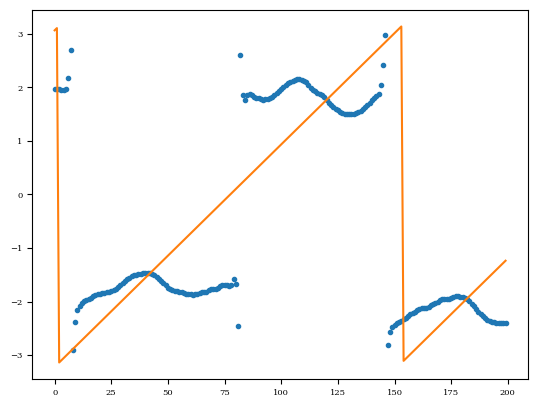

In [69]:
plt.plot(course, '.')
plt.plot(circle_angle)

In [70]:
if 1:
    ax = layout.axes[('math', 'math_ellipse')]
else:
    fig = plt.figure(figsize=(3,3))
    ax = fig.add_subplot(111)

# find 1 rotation to make dashed blue line look nice
ix_cross = np.where(np.abs(np.diff(circle_angle))>0.2)[0]
try:
    npoints_1_rotation = ix_cross[1] - ix_cross[0]+1
except:
    npoints_1_rotation = ix_cross[0]

ax.set_aspect('equal')
ax.plot(circle_x[0:npoints_1_rotation], circle_y[0:npoints_1_rotation], '--', color='blue', linewidth=1, zorder=-3)
ax.plot(course_x, course_y, '.', markerfacecolor='black', linewidth=0, zorder=-2, alpha=0.5, markeredgecolor='none')

AM_0_0 = unifying_algo_fit.iloc[best_ix].AM_0_0
AM_0_1 = unifying_algo_fit.iloc[best_ix].AM_0_1
AM_1_0 = unifying_algo_fit.iloc[best_ix].AM_1_0
AM_1_1 = unifying_algo_fit.iloc[best_ix].AM_1_1
AM = np.array([[AM_0_0, AM_0_1], [AM_1_0, AM_1_1]])

if unifying_algo_fit.iloc[bootstrap_n].tx is not None:
    tx = unifying_algo_fit.iloc[bootstrap_n].tx
    ty = unifying_algo_fit.iloc[bootstrap_n].ty
    AMt = np.eye(3)
    AMt[0:2,0:2] = AM
    AMt[0,2] = tx
    AMt[1,2] = ty
    AM = AMt
else:
    tx = 0
    ty = 0

if AM.shape[0] == 2:
    warped_fit = AM@circle_xy
elif AM.shape[0] == 3:
    abs_course_fit_xy = np.vstack((circle_xy, np.ones_like(circle_xy[0,:])))
    warped_fit = AM@abs_course_fit_xy

magenta_ellipse = warped_fit
ax.plot(magenta_ellipse[0,0:npoints_1_rotation], magenta_ellipse[1,0:npoints_1_rotation], '.', markersize=1, color='magenta', linewidth=1, zorder=-2)

total_rotation, major_axis, minor_axis, Vt, translation = decompose_affine(AM)

if 1:
    # draw some reference lines

    R = np.array([[np.cos(total_rotation), -np.sin(total_rotation)], 
                  [np.sin(total_rotation), np.cos(total_rotation)]])
    S = np.diag([major_axis, minor_axis]) #np.diag(np.linalg.svd(AM)[1])

    if S.shape[0] == 3:
        Ra = np.eye(3)
        Ra[0:2,0:2] = R
        R = Ra
    RS = R@S #R.T@S@R
    
    RSt = np.eye(3)
    RSt[0:2,0:2] = RS[0:2,0:2]
        
    RSt[0,2] = tx
    RSt[1,2] = ty
    
    xs = np.linspace(0, 1, 3)
    yline = np.vstack((xs*0, xs, np.ones_like(xs)))
    xline = np.vstack((xs, xs*0, np.ones_like(xs)))
    
    ax.plot(yline[0,:], yline[1,:], ':', color='orange', linewidth=0.6, zorder=-10)
    ax.plot(xline[0,:], xline[1,:], ':', color='green', linewidth=0.6, zorder=-10)
    
    ax.plot( (RSt@yline)[0,:], (RSt@yline)[1,:], '-', color='orange', linewidth=0.6, zorder=-1)
    ax.plot( (RSt@xline)[0,:], (RSt@xline)[1,:], '-', color='green', linewidth=0.6, zorder=-1)

ax.set_ylim(-1.2, 1.2)
fifi.mpl_functions.adjust_spines(ax, [])
ax.set_rasterization_zorder(0)

In [71]:
layout.append_figure_to_layer(layout.figures['math'], 'math', cleartarget=True)
layout.write_svg(FIGURE_NAME)